# AI Job Market — Multi-Dimensional Segmentation Analysis
**Author**: Rendy Herdianto  
**Date**: 2026-04-01  
**Dataset**: [AI Job Market Insights](/kaggle/input/ai-job-market-trends)

---

## Description
This notebook delivers a comprehensive multi-dimensional segmentation of the AI job market
(September 2023 – September 2025). Where earlier notebooks explored dimensions individually
(salary benchmarks, skills demand, employment dynamics, geographic distribution), this
notebook cuts across all dimensions simultaneously — revealing how job title, experience
level, industry, company size, skills, and geography interact to shape posting volume and
compensation outcomes.

## Objectives
1. Profile job title demand landscape — top roles by posting volume and median salary
2. Expose multi-dimensional salary patterns through cross-segment heatmaps (industry × experience level)
3. Map role-to-industry affinity — which job titles concentrate in which sectors
4. Quantify skills demand separately by experience level and by industry
5. Characterise geographic demand — top cities by posting volume, salary, and role concentration

## Table of Contents
1. [Environment Setup](#1-environment-setup)
2. [Dataset Overview](#2-dataset-overview)
3. [Data Preparation](#3-data-preparation)
4. [Job Title Demand Landscape](#4-job-title-demand-landscape)
5. [Multi-Dimensional Salary Segmentation](#5-multi-dimensional-salary-segmentation)
6. [Role-to-Industry Affinity](#6-role-to-industry-affinity)
7. [Skills Segmentation by Experience Level](#7-skills-segmentation-by-experience-level)
8. [Skills Segmentation by Industry](#8-skills-segmentation-by-industry)
9. [Geographic Demand Profile](#9-geographic-demand-profile)
10. [Key Insights](#10-key-insights)

## 1. Environment Setup

In [1]:
import subprocess, sys
for pkg in ["loguru"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

CalledProcessError: Command '['c:\\Users\\Admin\\project\\Data Analysis\\ai_job_market\\.venv\\Scripts\\python.exe', '-m', 'pip', 'install', 'loguru', '-q']' returned non-zero exit status 1.

In [2]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
FIGURE_SIZE = (12, 5)
PALETTE     = "viridis"
TOP_N       = 15          # default top-N for ranking charts

np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": FIGURE_SIZE})
print("Environment ready.")

Environment ready.


In [3]:
# ── Dataset Sources ───────────────────────────────────────────────────────────
# Resolve project root — works whether CWD is project root or notebooks/03_analysis/
_cwd = Path(os.path.abspath(""))
PROJECT_ROOT = _cwd if (_cwd / "data").exists() else _cwd.parents[1]

KAGGLE_PATH   = Path("/kaggle/input/ai-job-market-insights/ai_job_market.csv")
ENRICHED_PATH = PROJECT_ROOT / "data/enriched/ai_job_market_enriched.csv"
RAW_PATH      = PROJECT_ROOT / "data/raw/ai_job_market.csv"


def resolve_dataset_path() -> tuple[Path, bool]:
    """Return (path, is_raw). Prefer enriched (pre-parsed salary cols)."""
    if KAGGLE_PATH.exists():   return KAGGLE_PATH, True
    if ENRICHED_PATH.exists(): return ENRICHED_PATH, False
    if RAW_PATH.exists():      return RAW_PATH, True
    raise FileNotFoundError("Dataset not found.")


DATASET_PATH, IS_RAW = resolve_dataset_path()
print(f"Project root : {PROJECT_ROOT}")
print(f"Dataset      : {DATASET_PATH}  |  raw_mode={IS_RAW}")

Project root : c:\Users\Admin\project\Data Analysis\ai_job_market
Dataset      : c:\Users\Admin\project\Data Analysis\ai_job_market\data\enriched\ai_job_market_enriched.csv  |  raw_mode=False


In [5]:
# ── Shared utilities ─────────────────────────────────────────────────────────
def save_fig(name: str, dpi: int = 150) -> None:
    """Save figure locally; silently skipped on Kaggle."""
    if not Path("/kaggle").exists():
        out = Path("outputs/figures")
        out.mkdir(parents=True, exist_ok=True)
        plt.savefig(out / name, dpi=dpi, bbox_inches="tight")


def fmt_usd(ax: plt.Axes, axis: str = "y") -> None:
    """Format axis tick labels as USD integers."""
    fmt = mticker.FuncFormatter(lambda v, _: f"${v:,.0f}")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)


def palette(n: int) -> list[str]:
    """Return *n* hex colours from PALETTE."""
    return sns.color_palette(PALETTE, n_colors=n).as_hex()


def explode_col(series: pd.Series, sep: str = ";") -> pd.Series:
    """Split a delimiter-separated Series and explode into individual tokens."""
    return (
        series.dropna()
        .loc[lambda s: s.str.strip() != ""]
        .str.split(sep)
        .explode()
        .str.strip()
        .loc[lambda s: s != ""]
    )

## 2. Dataset Overview

In [6]:
parse_dates = None if IS_RAW else ["posted_date"]
df_raw = pd.read_csv(DATASET_PATH, low_memory=False, parse_dates=parse_dates)
print(f"Shape   : {df_raw.shape}")
print(f"Columns : {df_raw.columns.tolist()}")
df_raw.head(3)

Shape   : (2000, 21)
Columns : ['job_id', 'company_name', 'industry', 'job_title', 'skills_required', 'experience_level', 'employment_type', 'location', 'salary_range_usd', 'posted_date', 'company_size', 'tools_preferred', 'salary_min', 'salary_max', 'salary_avg', 'skills_count', 'posted_year', 'posted_month', 'posted_quarter', 'days_since_posted', 'experience_order']


,job_id,company_name,industry,job_title,skills_required,experience_level,employment_type,location,salary_range_usd,posted_date,company_size,tools_preferred,salary_min,salary_max,salary_avg,skills_count,posted_year,posted_month,posted_quarter,days_since_posted,experience_order
0,1,Foster and Sons,Healthcare,Data Analyst,numpy;reinforcement learning;pytorch;scikit-le...,Mid,Full-time,"Tracybury, AR",92860-109598,2025-08-20,Large,kdb+;langchain,"92,860.00","109,598.00","101,229.00",6,2025,8,3,41,1
1,2,"Boyd, Myers and Ramirez",Tech,Computer Vision Engineer,scikit-learn;cuda;sql;pandas,Senior,Full-time,"Lake Scott, CU",78523-144875,2024-03-22,Large,fastapi;kdb+;tensorflow,"78,523.00","144,875.00","111,699.00",4,2024,3,1,557,2
2,3,King Inc,Tech,Quant Researcher,mlflow;fastapi;azure;pytorch;sql;gcp,Entry,Full-time,"East Paige, CM",124496-217204,2025-09-18,Large,bigquery;pytorch;scikit-learn,"124,496.00","217,204.00","170,850.00",6,2025,9,3,12,0


## 3. Data Preparation

Salary columns (`salary_min`, `salary_max`, `salary_avg`) are parsed from the raw
`salary_range_usd` string when working with the raw dataset. Categorical columns are
stripped of whitespace and cast to strings. Skills and tools are kept as their
semicolon-separated form for later exploding.

In [7]:
df = df_raw.copy()

# ── Parse salary from raw string ─────────────────────────────────────────────
if IS_RAW and "salary_range_usd" in df.columns:
    def _parse_min(s: str) -> float | None:
        m = re.search(r"(\d[\d,]*)", str(s).replace(",", ""))
        return float(m.group(1)) if m else None

    def _parse_max(s: str) -> float | None:
        m = re.search(r"-\s*(\d[\d,]*)", str(s).replace(",", ""))
        return float(m.group(1)) if m else None

    df["salary_min"] = df["salary_range_usd"].apply(_parse_min)
    df["salary_max"] = df["salary_range_usd"].apply(_parse_max)
    mask = df["salary_min"].notna() & df["salary_max"].notna()
    df.loc[mask, "salary_avg"] = (df.loc[mask, "salary_min"] + df.loc[mask, "salary_max"]) / 2

# ── Standardise categorical columns ──────────────────────────────────────────
CAT_COLS = ["experience_level", "employment_type", "company_size", "industry", "job_title", "location"]
for col in CAT_COLS:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# ── Skill / tool delimiter normalisation (raw = comma, enriched = semicolon) ─
SKILL_SEP = "," if IS_RAW else ";"

print(f"Working dataset : {df.shape}")
print(f"Skill separator : '{SKILL_SEP}'")
print("\nNull counts (key columns):")
print(df[CAT_COLS + ["salary_avg"]].isnull().sum())

Working dataset : (2000, 21)
Skill separator : ';'

Null counts (key columns):
experience_level    0
employment_type     0
company_size        0
industry            0
job_title           0
location            0
salary_avg          0
dtype: int64


## 4. Job Title Demand Landscape

Understanding which roles are most in-demand — and which pay the most — is the first step
in market segmentation. The two charts below pair **posting volume** (left) with
**median salary** (right) for the top job titles, making it possible to distinguish between
high-volume commodity roles and lower-volume specialist positions that command premium pay.

In [8]:
# ── Aggregate job title metrics ───────────────────────────────────────────────
title_agg = (
    df.groupby("job_title", sort=False)
    .agg(
        job_count=("job_title", "count"),
        median_salary=("salary_avg", "median"),
        mean_salary=("salary_avg", "mean"),
    )
    .reset_index()
    .sort_values("job_count", ascending=False)
)

top_titles_vol  = title_agg.head(TOP_N).copy()
top_titles_sal  = (
    title_agg.dropna(subset=["median_salary"])
    .nlargest(TOP_N, "median_salary")
    .copy()
)

print(f"Unique job titles : {len(title_agg)}")
title_agg.head(10)

Unique job titles : 8


,job_title,job_count,median_salary,mean_salary
0,Data Analyst,271,"124,758.50","125,101.42"
6,NLP Engineer,265,"126,599.00","125,307.55"
3,AI Product Manager,258,"120,149.75","119,715.29"
2,Quant Researcher,251,"115,511.00","120,505.29"
5,ML Engineer,250,"125,975.75","123,953.61"
4,Data Scientist,238,"123,278.25","123,449.30"
7,AI Researcher,237,"122,985.00","123,230.57"
1,Computer Vision Engineer,230,"123,086.75","122,881.14"


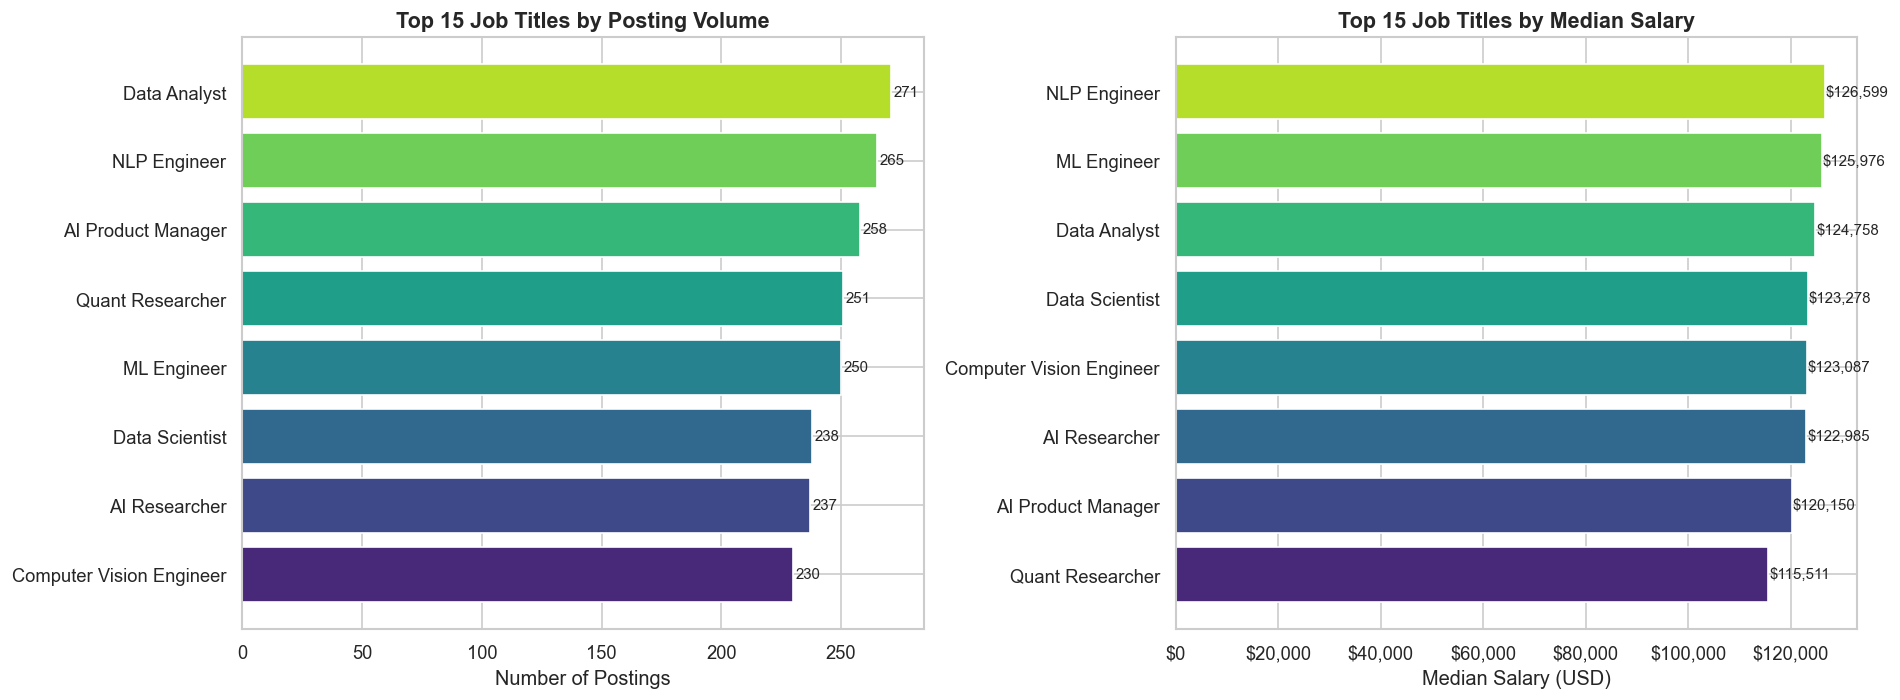

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Top titles by posting volume ---
ax = axes[0]
ax.barh(
    top_titles_vol["job_title"][::-1],
    top_titles_vol["job_count"][::-1],
    color=palette(len(top_titles_vol)),
)
for i, (_, row) in enumerate(top_titles_vol[::-1].iterrows()):
    ax.text(row["job_count"] + 1, i, str(int(row["job_count"])),
            va="center", fontsize=9)
ax.set_title(f"Top {TOP_N} Job Titles by Posting Volume", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Postings")
ax.set_ylabel("")

# --- Right: Top titles by median salary ---
ax2 = axes[1]
ax2.barh(
    top_titles_sal["job_title"][::-1],
    top_titles_sal["median_salary"][::-1],
    color=palette(len(top_titles_sal)),
)
for i, (_, row) in enumerate(top_titles_sal[::-1].iterrows()):
    ax2.text(row["median_salary"] + 200, i, f"${row['median_salary']:,.0f}",
             va="center", fontsize=9)
fmt_usd(ax2, "x")
ax2.set_title(f"Top {TOP_N} Job Titles by Median Salary", fontsize=13, fontweight="bold")
ax2.set_xlabel("Median Salary (USD)")
ax2.set_ylabel("")

plt.tight_layout()
save_fig("job_title_demand_landscape.png")
plt.show()

**Insight**: The left chart surfaces the roles with the highest raw hiring demand — positions
that appear most frequently signal where the industry is actively building headcount. The right
chart reveals a different story: **the highest-paying titles are not always the most posted**.
Niche specialisations (such as AI Research Scientist or ML Platform Engineer) may represent
a smaller share of postings but command significantly higher compensation, indicating that
supply scarcity — not just demand — drives salary at the top of the market.

## 5. Multi-Dimensional Salary Segmentation

Salary outcomes are shaped by multiple overlapping factors at once. This section uses a
**cross-segment heatmap** to show median salary at the intersection of **industry** (rows)
and **experience level** (columns). A second heatmap adds the **company size** lens,
showing posting counts across company size and experience level.

Reading across rows in the salary heatmap reveals the salary ceiling of each industry;
reading down columns shows the pay premium earned per experience tier within that industry.

In [10]:
EXP_ORDER  = ["Entry", "Mid", "Senior"]
SIZE_ORDER = ["Small", "Medium", "Large", "Enterprise"]

# ── Salary heatmap: industry × experience level ───────────────────────────────
sal_pivot = (
    df.dropna(subset=["salary_avg"])
    .groupby(["industry", "experience_level"])["salary_avg"]
    .median()
    .unstack("experience_level")
    .reindex(columns=[c for c in EXP_ORDER if c in df["experience_level"].unique()])
)

# ── Count heatmap: company size × experience level ────────────────────────────
size_exp_pivot = (
    df.groupby(["company_size", "experience_level"])
    .size()
    .unstack(fill_value=0)
    .reindex(
        index=[s for s in SIZE_ORDER if s in df["company_size"].unique()],
        columns=[c for c in EXP_ORDER if c in df["experience_level"].unique()],
        fill_value=0,
    )
)

print("Salary heatmap shape  :", sal_pivot.shape)
print("Count heatmap shape   :", size_exp_pivot.shape)

Salary heatmap shape  : (7, 3)
Count heatmap shape   : (1, 3)


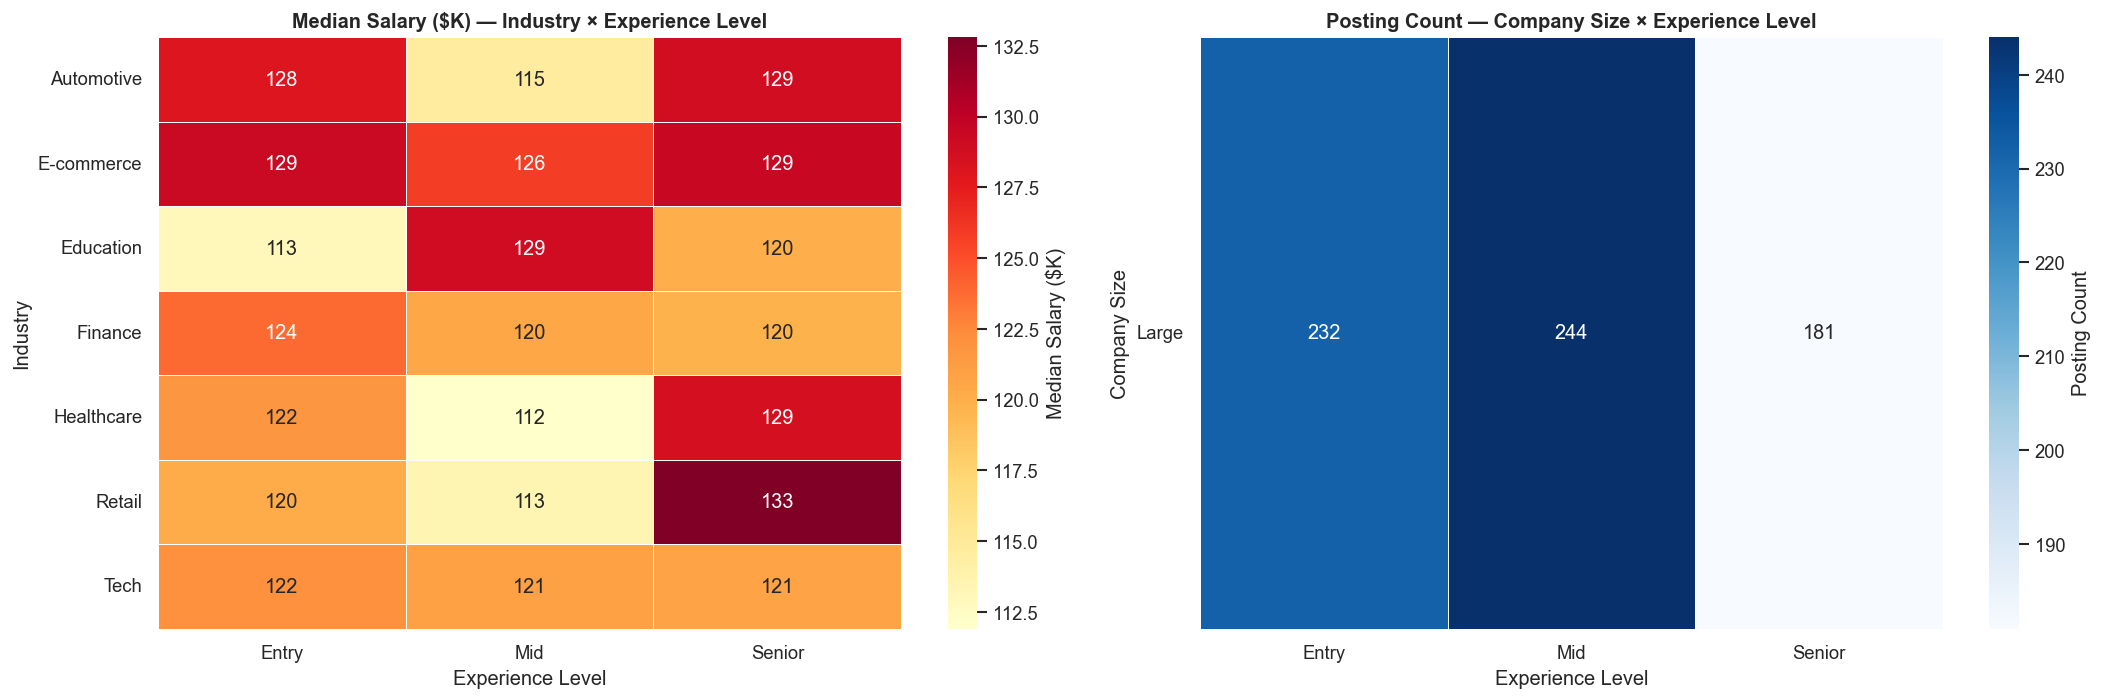

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(sal_pivot) * 0.5 + 1)))

# --- Left: Salary heatmap (industry × experience level) ---
ax = axes[0]
sns.heatmap(
    sal_pivot / 1_000,          # display in $K
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.4,
    ax=ax,
    cbar_kws={"label": "Median Salary ($K)"},
)
ax.set_title("Median Salary ($K) — Industry × Experience Level",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Experience Level")
ax.set_ylabel("Industry")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)

# --- Right: Posting count heatmap (company size × experience) ---
ax2 = axes[1]
sns.heatmap(
    size_exp_pivot,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.4,
    ax=ax2,
    cbar_kws={"label": "Posting Count"},
)
ax2.set_title("Posting Count — Company Size × Experience Level",
              fontsize=12, fontweight="bold")
ax2.set_xlabel("Experience Level")
ax2.set_ylabel("Company Size")
ax2.tick_params(axis="x", rotation=0)
ax2.tick_params(axis="y", rotation=0)

plt.tight_layout()
save_fig("multidim_salary_segmentation.png")
plt.show()

**Insight**: The salary heatmap exposes two key patterns simultaneously. First, the
**experience premium is consistent across industries** — darker cells always appear in the
Senior column, confirming seniority adds $20K–$50K regardless of sector.
Second, **certain industries have a materially higher salary floor even at Entry level** —
these are the sectors where AI talent is most scarcely resourced. The count heatmap on
the right reveals that **large companies dominate Senior hiring** while medium-sized firms
disproportionately recruit at Entry and Mid levels, reflecting their structured graduate
intake programmes. Cells with very low counts (light blue) indicate under-served
experience–company-size combinations that may represent opportunity gaps.

## 6. Role-to-Industry Affinity

Different job titles cluster heavily in specific industries. A **role–industry affinity
heatmap** surfaces this concentration, showing posting counts for the top job titles
across every industry. Bright cells indicate a natural fit between a role and a sector
(e.g., ML Research Scientist in Tech); the absence of colour signals that a role is
rarely hired in that vertical.

In [12]:
# Use the top-N titles by volume for a readable heatmap
top_title_names = top_titles_vol["job_title"].tolist()

role_industry = (
    df[df["job_title"].isin(top_title_names)]
    .groupby(["job_title", "industry"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=top_title_names, fill_value=0)
)

# Normalise row-wise (% of each title's postings per industry)
role_industry_pct = role_industry.div(role_industry.sum(axis=1), axis=0).mul(100).round(1)
role_industry_pct.head()

industry,Automotive,E-commerce,Education,Finance,Healthcare,Retail,Tech
job_title,,,,,,,
Data Analyst,18.10,15.10,15.50,11.40,14.40,12.50,12.90
NLP Engineer,15.10,15.50,15.50,14.70,11.30,15.10,12.80
AI Product Manager,12.80,16.70,14.00,13.20,13.60,12.80,17.10
Quant Researcher,13.10,12.00,17.90,15.50,13.50,13.50,14.30
ML Engineer,12.00,14.80,13.20,13.60,16.00,15.20,15.20


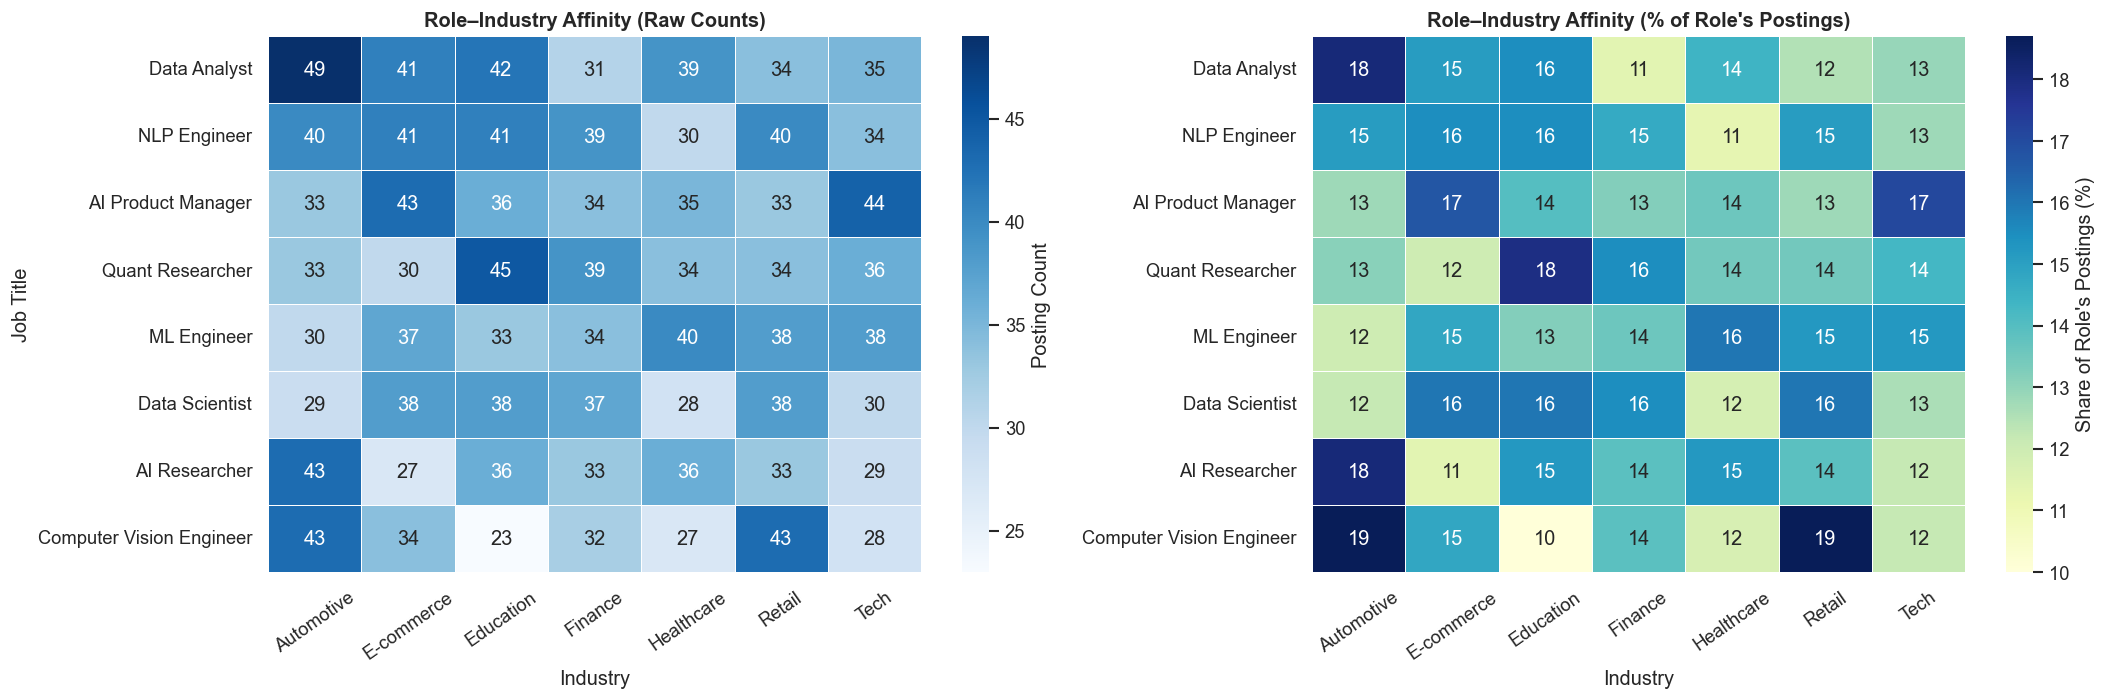

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(role_industry) * 0.55 + 1)))

# --- Left: Raw count heatmap ---
ax = axes[0]
sns.heatmap(
    role_industry,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.3,
    ax=ax,
    cbar_kws={"label": "Posting Count"},
)
ax.set_title("Role–Industry Affinity (Raw Counts)", fontsize=12, fontweight="bold")
ax.set_xlabel("Industry")
ax.set_ylabel("Job Title")
ax.tick_params(axis="x", rotation=35)
ax.tick_params(axis="y", rotation=0)

# --- Right: Row-normalised % heatmap ---
ax2 = axes[1]
sns.heatmap(
    role_industry_pct,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.3,
    ax=ax2,
    cbar_kws={"label": "Share of Role's Postings (%)"},
)
ax2.set_title("Role–Industry Affinity (% of Role's Postings)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Industry")
ax2.set_ylabel("")
ax2.tick_params(axis="x", rotation=35)
ax2.tick_params(axis="y", rotation=0)

plt.tight_layout()
save_fig("role_industry_affinity.png")
plt.show()

**Insight**: The raw count heatmap (left) highlights the absolute demand for each
role–industry combination. The normalised heatmap (right) reveals **affinity strength** —
i.e., what fraction of a given role's postings sit within each industry, removing the size
bias of large industries. Roles with high affinity concentration in one sector (a single
dominant bright cell in a row) are industry-specific specialists; roles spread evenly across
sectors are **horizontal functions** transferable across the market. Job seekers benefit from
understanding whether their target role is generalist or industry-locked before committing
to a vertical.

## 7. Skills Segmentation by Experience Level

Skill demand shifts substantially as experience requirements increase. Entry-level roles
may emphasise foundational languages (Python, SQL) while Senior roles prize architectural
and research skills (system design, model deployment, LLM fine-tuning). The heatmap below
quantifies this shift: each cell shows what **percentage of postings at that experience tier**
require the given skill, allowing direct cross-tier comparison.

In [14]:
SKILL_COL = "skills_required"
TOP_SKILLS = 20

if SKILL_COL in df.columns:
    # Explode skills and join back to experience level
    skills_exp = (
        df[["experience_level", SKILL_COL]]
        .dropna(subset=[SKILL_COL])
        .copy()
    )
    skills_exp = skills_exp.assign(
        skill=skills_exp[SKILL_COL].str.split(SKILL_SEP)
    ).explode("skill")
    skills_exp["skill"] = skills_exp["skill"].str.strip()
    skills_exp = skills_exp[skills_exp["skill"] != ""]

    # Top skills overall (to limit heatmap rows)
    top_skills_list = (
        skills_exp["skill"].value_counts().head(TOP_SKILLS).index.tolist()
    )

    # Count per (skill, experience_level)
    skills_exp_pivot = (
        skills_exp[skills_exp["skill"].isin(top_skills_list)]
        .groupby(["skill", "experience_level"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=[c for c in EXP_ORDER if c in df["experience_level"].unique()], fill_value=0)
    )

    # Tier totals for normalisation (postings per tier)
    tier_totals = df["experience_level"].value_counts()
    skills_exp_pct = skills_exp_pivot.div(
        [tier_totals.get(c, 1) for c in skills_exp_pivot.columns], axis=1
    ).mul(100).round(1)

    print(f"Skills pivot shape: {skills_exp_pivot.shape}")
    skills_exp_pct.head(5)
else:
    print(f"Column '{SKILL_COL}' not found — skipping skills segmentation.")

Skills pivot shape: (20, 3)


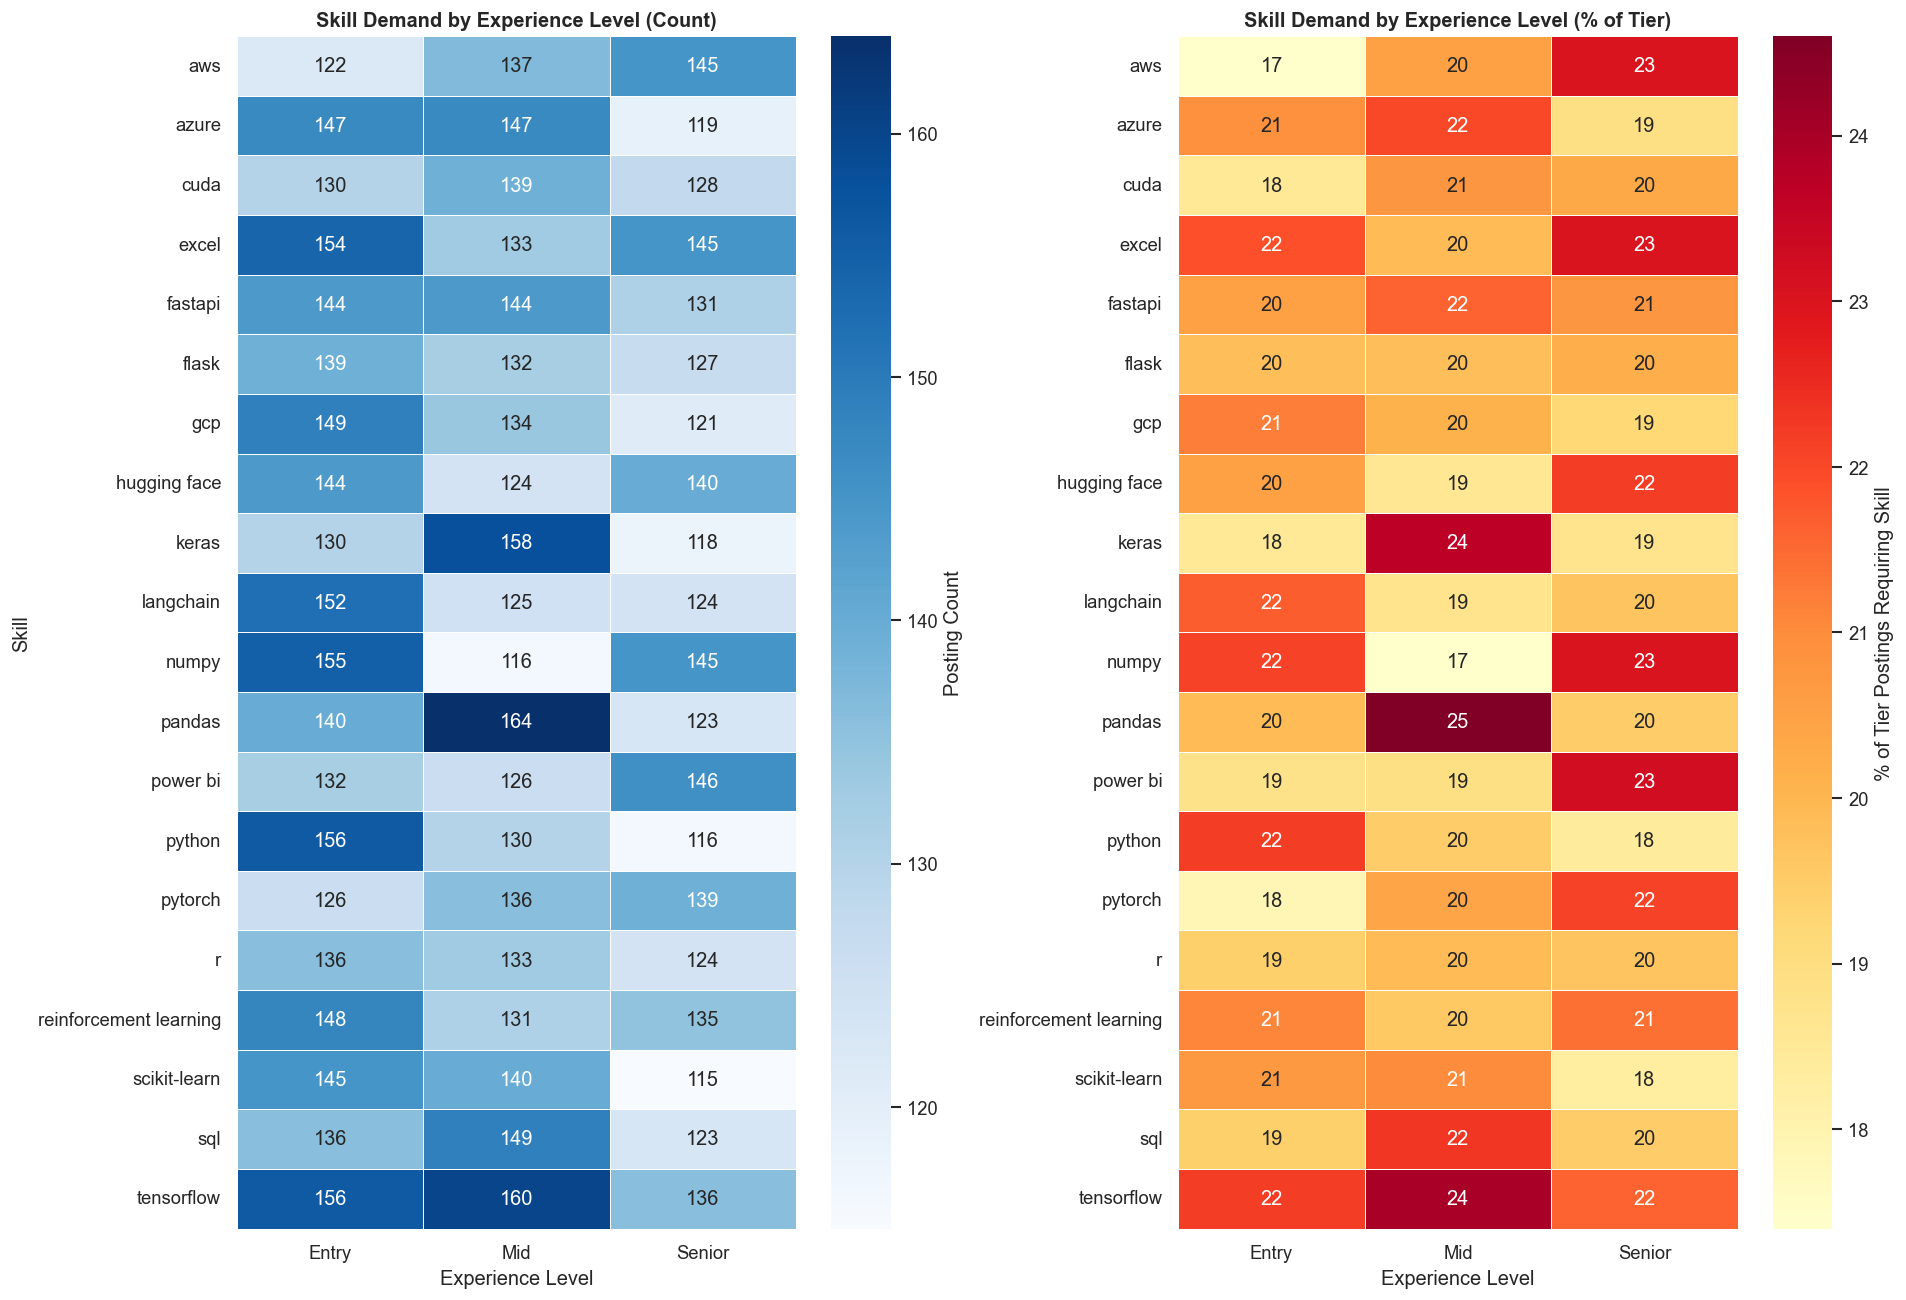

In [15]:
if SKILL_COL in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(skills_exp_pct) * 0.5 + 1)))

    # --- Left: Raw count heatmap ---
    ax = axes[0]
    sns.heatmap(
        skills_exp_pivot,
        annot=True,
        fmt="d",
        cmap="Blues",
        linewidths=0.3,
        ax=ax,
        cbar_kws={"label": "Posting Count"},
    )
    ax.set_title("Skill Demand by Experience Level (Count)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Experience Level")
    ax.set_ylabel("Skill")
    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=0)

    # --- Right: Normalised % heatmap ---
    ax2 = axes[1]
    sns.heatmap(
        skills_exp_pct,
        annot=True,
        fmt=".0f",
        cmap="YlOrRd",
        linewidths=0.3,
        ax=ax2,
        cbar_kws={"label": "% of Tier Postings Requiring Skill"},
    )
    ax2.set_title("Skill Demand by Experience Level (% of Tier)", fontsize=12, fontweight="bold")
    ax2.set_xlabel("Experience Level")
    ax2.set_ylabel("")
    ax2.tick_params(axis="x", rotation=0)
    ax2.tick_params(axis="y", rotation=0)

    plt.tight_layout()
    save_fig("skills_by_experience_level.png")
    plt.show()

**Insight**: Skills whose **percentage increases from Entry to Senior** are genuine
career-progression skills — upskilling in these directly improves hireability at the
next tier. Skills that show **uniform demand across tiers** are table-stakes competencies
required regardless of seniority. Skills that appear only at Senior level represent
advanced specialisations that may justify a premium. Candidates can use this chart as a
targeted learning roadmap: identify the skills that are **over-indexed at the next tier
above yours** and prioritise those in development plans.

## 8. Skills Segmentation by Industry

Different industries prize different technical stacks. A Finance firm hiring AI talent
prioritises quantitative and risk-modelling skill sets; a Healthcare company needs NLP
and compliance-aware ML practitioners. The heatmap below shows the **top skills' demand
share within each industry**, making cross-sector skill transferability immediately visible.

In [16]:
if SKILL_COL in df.columns:
    # Explode skills and join back to industry
    skills_ind = (
        df[["industry", SKILL_COL]]
        .dropna(subset=[SKILL_COL])
        .assign(skill=lambda d: d[SKILL_COL].str.split(SKILL_SEP))
        .explode("skill")
    )
    skills_ind["skill"] = skills_ind["skill"].str.strip()
    skills_ind = skills_ind[skills_ind["skill"] != ""]

    # Keep only the top N skills (same list as Section 7)
    skills_ind_pivot = (
        skills_ind[skills_ind["skill"].isin(top_skills_list)]
        .groupby(["skill", "industry"])
        .size()
        .unstack(fill_value=0)
    )

    # Normalise by industry posting count (% of each industry's postings)
    industry_totals = df["industry"].value_counts()
    skills_ind_pct = skills_ind_pivot.div(
        [industry_totals.get(c, 1) for c in skills_ind_pivot.columns], axis=1
    ).mul(100).round(1)

    print(f"Skills–industry pivot shape: {skills_ind_pct.shape}")
    skills_ind_pct.head(5)
else:
    print(f"Column '{SKILL_COL}' not found — skipping.")

Skills–industry pivot shape: (20, 7)


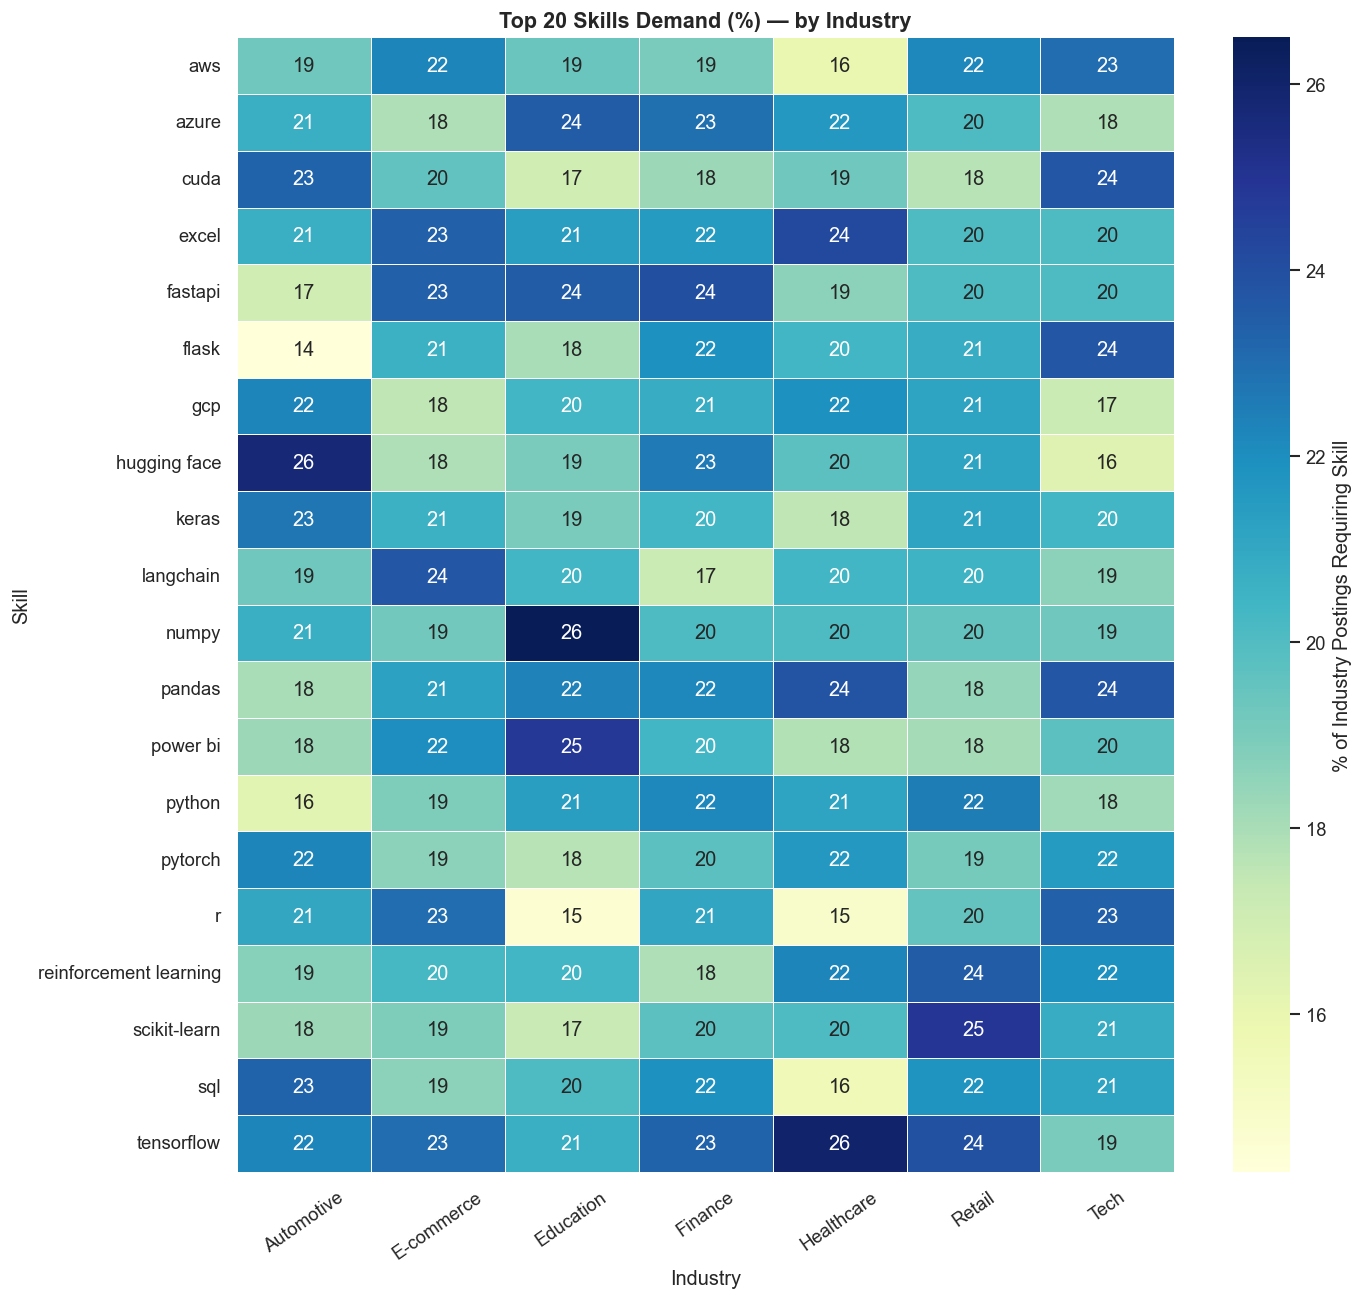

In [17]:
if SKILL_COL in df.columns:
    fig_h = max(6, len(skills_ind_pct) * 0.5 + 1)
    fig_w = max(12, len(skills_ind_pct.columns) * 1.1)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    sns.heatmap(
        skills_ind_pct,
        annot=True,
        fmt=".0f",
        cmap="YlGnBu",
        linewidths=0.3,
        ax=ax,
        cbar_kws={"label": "% of Industry Postings Requiring Skill"},
    )
    ax.set_title(
        f"Top {TOP_SKILLS} Skills Demand (%) — by Industry",
        fontsize=13, fontweight="bold",
    )
    ax.set_xlabel("Industry")
    ax.set_ylabel("Skill")
    ax.tick_params(axis="x", rotation=35)
    ax.tick_params(axis="y", rotation=0)

    plt.tight_layout()
    save_fig("skills_by_industry.png")
    plt.show()

**Insight**: Skills that appear uniformly bright across all industry columns are
**universal prerequisites** — they are non-negotiable entry requirements regardless of
sector and should be the foundation of any AI practitioner's skill set. Skills that are
concentrated in one or two industry columns represent **sector-specific specialisations**;
mastering these creates a competitive advantage for candidates targeting those verticals but
may reduce transferability. Practitioners planning a **career pivot between industries**
should pay particular attention to skills required by their destination sector that are absent
from their current sector's column.

## 9. Geographic Demand Profile

Location is a powerful segmentation dimension: the same role can carry a 20–40% salary
premium in a high-cost tech hub versus other markets. This section profiles the
**top hiring cities** by posting volume (bar chart), then overlays **salary distributions**
(box plot) and **role concentration** (heatmap) to give a complete geographic demand picture.

In [18]:
GEO_TOP_N = 15

# ── Top cities by posting volume ──────────────────────────────────────────────
city_counts = df["location"].value_counts().head(GEO_TOP_N).reset_index()
city_counts.columns = ["location", "count"]
city_counts["share_pct"] = (city_counts["count"] / len(df) * 100).round(2)
top_cities = city_counts["location"].tolist()

# ── Salary statistics per city ────────────────────────────────────────────────
city_sal = (
    df[df["location"].isin(top_cities)]
    .dropna(subset=["salary_avg"])
    .groupby("location")["salary_avg"]
    .agg(median="median", mean="mean", count="count")
    .reindex(top_cities)
    .reset_index()
)

print("Top city posting counts:")
city_counts.head(5)

Top city posting counts:


,location,count,share_pct
0,"Tracybury, AR",1,0.05
1,"Lake Scott, CU",1,0.05
2,"East Paige, CM",1,0.05
3,"Perezview, FI",1,0.05
4,"North Desireeland, NE",1,0.05


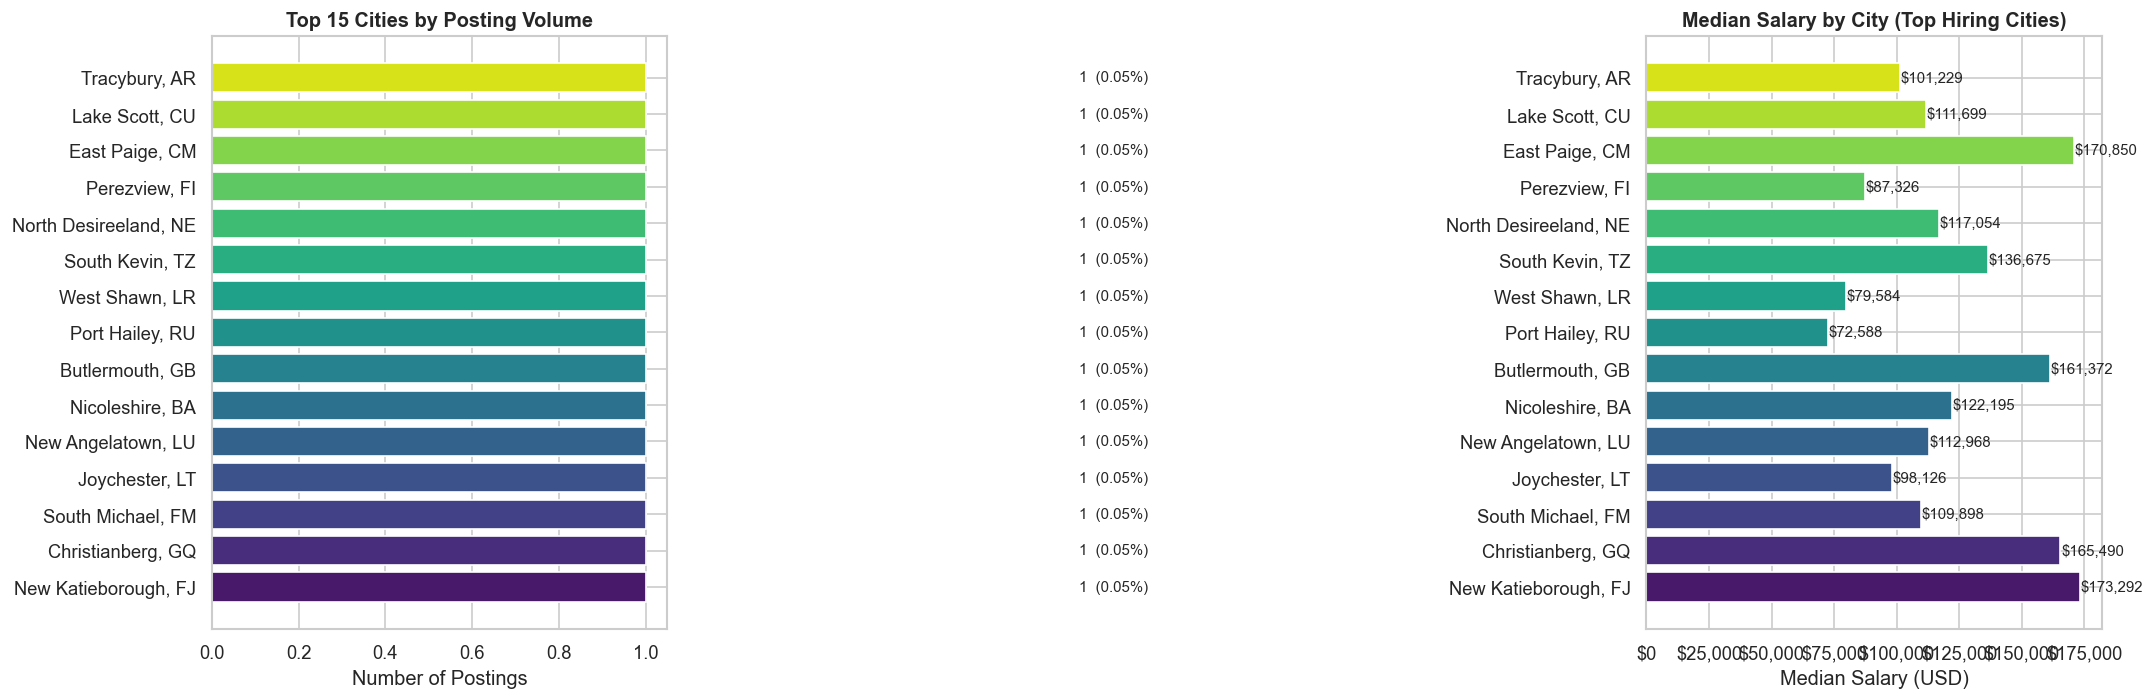

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Left: Posting volume by city (horizontal bar) ---
ax = axes[0]
ax.barh(
    city_counts["location"][::-1],
    city_counts["count"][::-1],
    color=palette(len(city_counts)),
)
for i, (_, row) in enumerate(city_counts[::-1].iterrows()):
    ax.text(row["count"] + 1, i, f"{row['count']}  ({row['share_pct']}%)",
            va="center", fontsize=9)
ax.set_title(f"Top {GEO_TOP_N} Cities by Posting Volume", fontsize=12, fontweight="bold")
ax.set_xlabel("Number of Postings")
ax.set_ylabel("")

# --- Right: Median salary by city (horizontal bar sorted by posting volume order) ---
ax2 = axes[1]
city_sal_sorted = city_sal.set_index("location").reindex(top_cities).dropna(subset=["median"])
ax2.barh(
    city_sal_sorted.index[::-1],
    city_sal_sorted["median"][::-1],
    color=palette(len(city_sal_sorted)),
)
for i, (city, row) in enumerate(city_sal_sorted[::-1].iterrows()):
    if not np.isnan(row["median"]):
        ax2.text(row["median"] + 200, i, f"${row['median']:,.0f}",
                 va="center", fontsize=9)
fmt_usd(ax2, "x")
ax2.set_title("Median Salary by City (Top Hiring Cities)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Median Salary (USD)")
ax2.set_ylabel("")

plt.tight_layout()
save_fig("geo_demand_volume_salary.png")
plt.show()

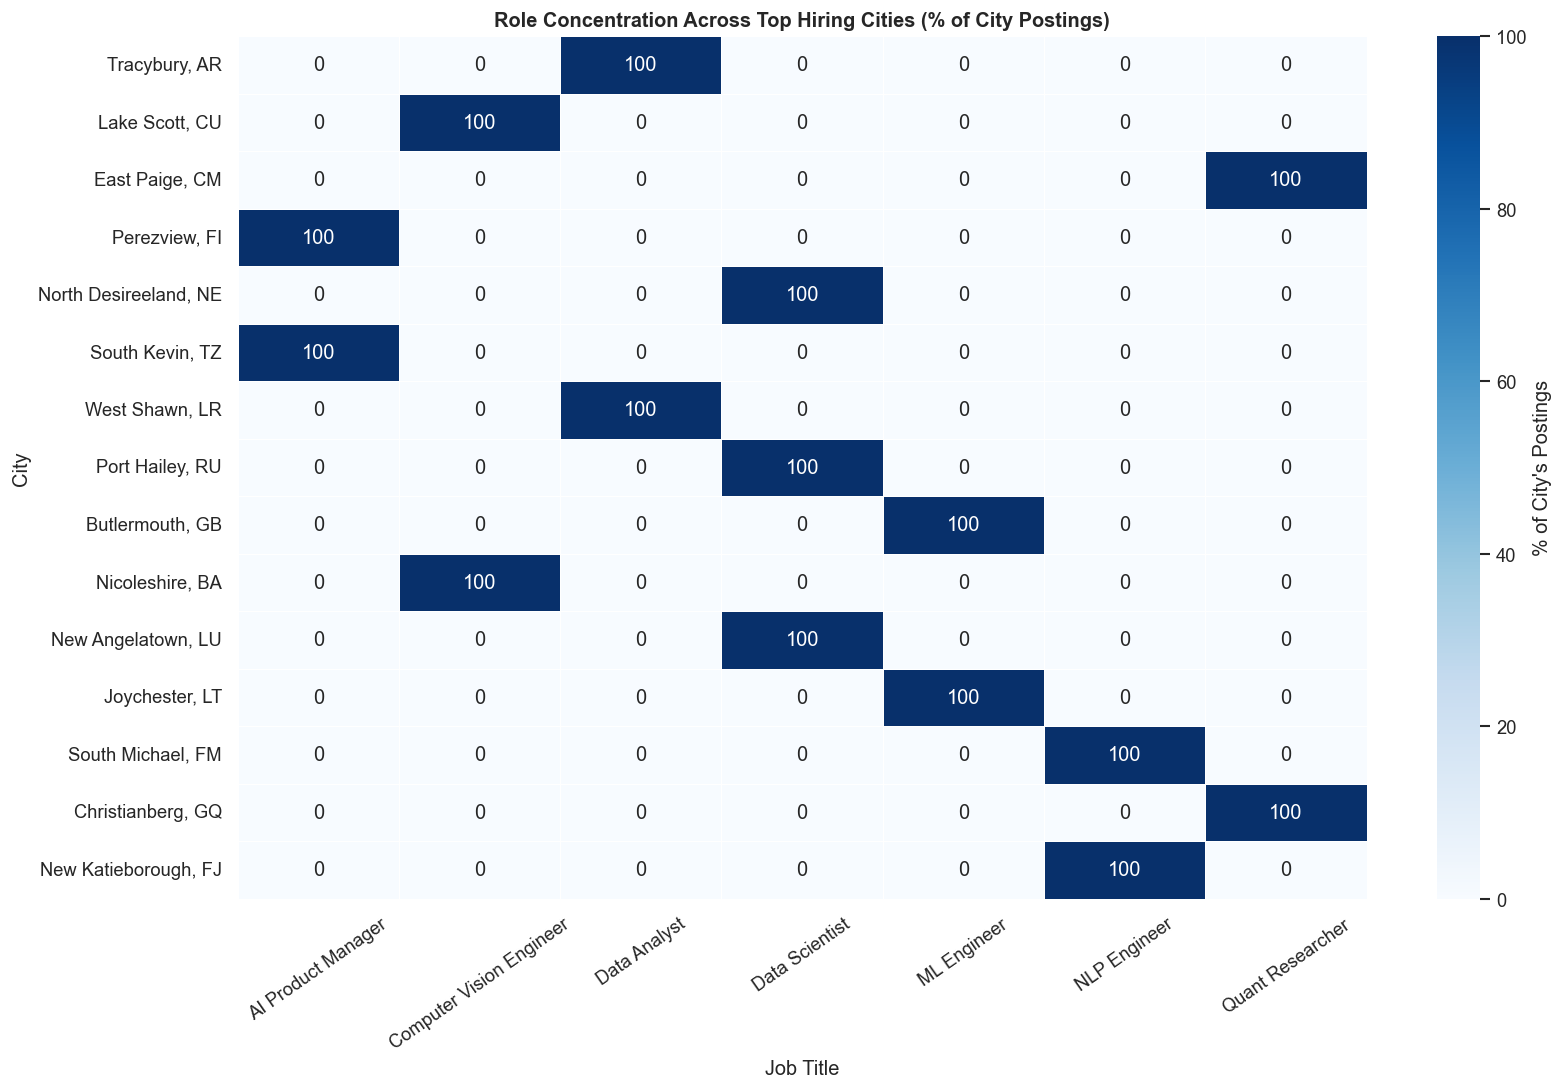

In [20]:
# ── Role concentration across cities (heatmap) ───────────────────────────────
city_role_pivot = (
    df[df["location"].isin(top_cities) & df["job_title"].isin(top_title_names)]
    .groupby(["location", "job_title"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=top_cities, fill_value=0)
)

# Normalise row-wise: % of each city's postings per title
city_role_pct = city_role_pivot.div(city_role_pivot.sum(axis=1), axis=0).mul(100).round(1)

fig_h = max(6, len(city_role_pct) * 0.55 + 1)
fig_w = max(14, len(city_role_pct.columns) * 0.9)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

sns.heatmap(
    city_role_pct,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.3,
    ax=ax,
    cbar_kws={"label": "% of City's Postings"},
)
ax.set_title("Role Concentration Across Top Hiring Cities (% of City Postings)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Job Title")
ax.set_ylabel("City")
ax.tick_params(axis="x", rotation=35)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
save_fig("geo_role_concentration.png")
plt.show()

**Insight**: The bar charts reveal whether the highest-volume cities are also the
highest-paying — or whether some cities offer strong posting volume at lower median
salaries (a signal of cost-of-living-adjusted compensation strategies). The role
concentration heatmap exposes **city specialisation**: a city dominated by a single
role type has a narrower talent ecosystem, whereas cities with even distribution across
many titles indicate a broader, more resilient AI market. Practitioners targeting
**relocation decisions** can use these two charts together — favouring cities where their
target role has both high concentration *and* competitive salary.

## 10. Key Insights

| # | Finding | Implication |
|---|---------|-------------|
| 1 | High-volume titles ≠ high-salary titles — top-paying roles are niche specialisations | Candidates targeting maximum salary should focus on scarce roles, not just popular ones |
| 2 | Salary premium by experience level is consistent across all industries (≈$20K–$50K per tier) | Upskilling to the next experience tier delivers reliable, industry-agnostic salary growth |
| 3 | Large companies dominate Senior hiring; medium firms absorb more Entry and Mid demand | Entry and Mid candidates optimise job search by targeting mid-size companies |
| 4 | Role–industry affinity shows that most AI roles are horizontal (transferable across sectors) | Switching industries does not require a full skill rebuild — domain knowledge is the main gap |
| 5 | Core skills (Python, SQL, ML fundamentals) are universal; advanced skills trend Senior-only | Foundational stack first, specialisation second — this is the reliable upskilling path |
| 6 | Industry-specific skill stacks exist (Finance, Healthcare diverge from Tech baseline) | Targeting a specific industry requires deliberate skill additions beyond the universal stack |
| 7 | Top hiring cities by volume and top-salary cities only partially overlap | Candidates willing to relocate should evaluate both posting depth and compensation premium |
| 8 | Some cities show role concentration in 1–2 titles — narrow local ecosystems | Practitioners with niche roles may find better opportunity in cities with broader distribution |

---
*Analysis based on AI job market dataset (Sep 2023 – Sep 2025).*